In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pytz
import os
from glob import glob
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import summary_table
from sklearn.model_selection import train_test_split as tts
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,accuracy_score, auc, average_precision_score

In [2]:
root="/mnt/c/Users/soggy/OneDrive - USNH/Dox/PSIREN/ocBottleTracker/"
fldr=root+"supportingData/"
prefix=lambda x: "{}_2022_fall_travel_distance_by_Q_all_*.csv".format(x)
watersheds = "ipswich don chicago ".split()
data={}
for watershed in watersheds:
    data[watershed]={}
    paths = glob(fldr+prefix(watershed))
    for path in paths:
        print(path)
        station=path.split('Q_all_')[1].split('.csv')[0]
        data[watershed][station] = pd.read_csv(path,index_col=0,parse_dates=True)
prefix=lambda x: "{}_2024_spring_travel_distance_by_Q_all_*.csv".format(x)
watersheds = "anacostia miami sfbay socal".split()
for watershed in watersheds:
    data[watershed]={}
    paths = glob(fldr+prefix(watershed))
    for path in paths:
        print(path)
        station=path.split('Q_all_')[1].split('.csv')[0]
        data[watershed][station] = pd.read_csv(path,index_col=0,parse_dates=True).rename(columns={'60':'00060',60:"00060"})

/mnt/c/Users/soggy/OneDrive - USNH/Dox/PSIREN/ocBottleTracker/supportingData/ipswich_2022_fall_travel_distance_by_Q_all_01101500.csv
/mnt/c/Users/soggy/OneDrive - USNH/Dox/PSIREN/ocBottleTracker/supportingData/ipswich_2022_fall_travel_distance_by_Q_all_01102000.csv
/mnt/c/Users/soggy/OneDrive - USNH/Dox/PSIREN/ocBottleTracker/supportingData/ipswich_2022_fall_travel_distance_by_Q_all_IS163.csv
/mnt/c/Users/soggy/OneDrive - USNH/Dox/PSIREN/ocBottleTracker/supportingData/ipswich_2022_fall_travel_distance_by_Q_all_SB.csv
/mnt/c/Users/soggy/OneDrive - USNH/Dox/PSIREN/ocBottleTracker/supportingData/don_2022_fall_travel_distance_by_Q_all_HY019.csv
/mnt/c/Users/soggy/OneDrive - USNH/Dox/PSIREN/ocBottleTracker/supportingData/don_2022_fall_travel_distance_by_Q_all_HY022.csv
/mnt/c/Users/soggy/OneDrive - USNH/Dox/PSIREN/ocBottleTracker/supportingData/don_2022_fall_travel_distance_by_Q_all_HY062.csv
/mnt/c/Users/soggy/OneDrive - USNH/Dox/PSIREN/ocBottleTracker/supportingData/don_2022_fall_travel_d

Index(['Oyster', '00060', 'Qmax_Oyster', 'lat_Oyster', 'lon_Oyster',
       'totdasqkm_Oyster', 'slope_mean_Oyster', 'slope_std_Oyster', 'Prawn',
       'Qmax_Prawn', 'lat_Prawn', 'lon_Prawn', 'totdasqkm_Prawn',
       'slope_mean_Prawn', 'slope_std_Prawn', 'Fire Coral', 'Qmax_Fire Coral',
       'lat_Fire Coral', 'lon_Fire Coral', 'totdasqkm_Fire Coral',
       'slope_mean_Fire Coral', 'slope_std_Fire Coral', 'Dolphinfish',
       'Qmax_Dolphinfish', 'lat_Dolphinfish', 'lon_Dolphinfish',
       'totdasqkm_Dolphinfish', 'slope_mean_Dolphinfish',
       'slope_std_Dolphinfish', 'Blue whale', 'Qmax_Blue whale',
       'lat_Blue whale', 'lon_Blue whale', 'totdasqkm_Blue whale',
       'slope_mean_Blue whale', 'slope_std_Blue whale', 'Puffer Fish',
       'Qmax_Puffer Fish', 'lat_Puffer Fish', 'lon_Puffer Fish',
       'totdasqkm_Puffer Fish', 'slope_mean_Puffer Fish',
       'slope_std_Puffer Fish', 'Orange Sea Cucumber',
       'Qmax_Orange Sea Cucumber', 'lat_Orange Sea Cucumber',
     

<Axes: xlabel='datetime'>

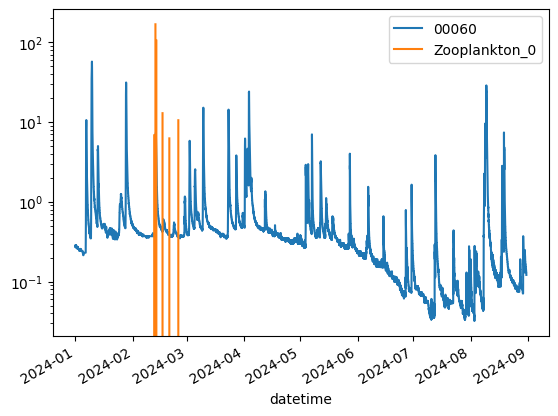

In [3]:
print(data["anacostia"]['01650500'].columns)
data["anacostia"]['01650500']["00060 Zooplankton_0".split()].plot(logy=True)

In [4]:
for ws,tz in zip(["ipswich","don","chicago","anacostia","miami","sfbay","socal"],["US/Eastern","US/Eastern","US/Central","US/Eastern","US/Eastern","US/Pacific","US/Pacific"]):
    for k in data[ws].keys():
        data[ws][k]=data[ws][k].set_index(pd.DatetimeIndex([pd.Timestamp(x).tz_convert(tz) for x in data[ws][k].index]))

<Axes: >

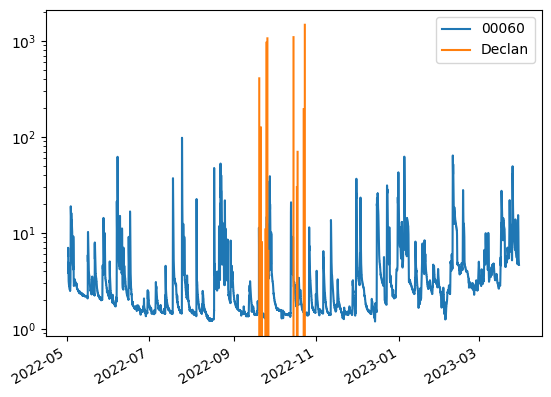

In [5]:
data["don"]['HY019']["00060 Declan".split()].plot(logy=True)

In [6]:
sites = """01650800
01649190
01650500
01649500
HY113
HY062
HY022
HY019
SB
IS163
01101500
01102000
11098000
11088500
11102300
11048600
11087020
S27
S22
S21
S30C
05535000
05534500
GV
05536000
GTB
GVD
RMB
WCY
WDB""".split()

areas="""16.7
33.9
54.5
189
33.2
35.7
128
318
4.46
3.53
115
324""".split()+[14.0, 41.4,55.9,321,1145]+"""12.9
26.8
361
4292
33.7
51.0
157
259
13.0
21.2
8.04
186
192""".split()

In [7]:
areas = dict([(k,float(v)) for k,v in zip(sites,areas)])
# These areas are going to be used to scale discharge based on location along the NHD network.  The discharge values are 
#  associated with catchment area where known, otherwise we use the NHD+ derived areas from the point of deployment.(This should be updated with known catchment areas.)
#  Assume area differences are based on slightly different deployment locations from gages.
widths={"05535000":4.58,"05534500":4.7,"GV":18.1,"05536000":14.75,
       "01102000":10.97,"01101500":19.5,"IS163":3.0,"SB":4.3,
       "HY113":7.8,"HY022":13.9,"HY062":6,"HY019":18.9,
       "01649190": 10.0,"01649500": 23.7,"01650500": 15.0,"01650800": 11.5,
       "S30C": 16.0, "S27": 16.5, "S22": 22.0, "S21": 9.8,
       "WDB":8.9,"WCY":7.0, "RMB":2.6, "GVD":11.6,"GTB":9.0,
       "11102300":69.4,"11098000":1.2,"11048600":2.09,"11087020":4.15,"11088500":6.375}
slopes={"05535000":0.01,"05534500":0.01,"GV":0.005,"05536000":0.005,
       "01102000":0.005,"01101500":0.005,"IS163":0.01,"SB":0.02,
       "HY113":0.005,"HY022":0.005,"HY062":0.01,"HY019":0.005,
       "01649190": 0.015,"01649500": 0.001,"01650500": 0.001,"01650800": 0.01,
       "S30C": 0.0005, "S27":0.0005, "S22": 0.0005,"S21":0.0005,
       "WDB":0.01,"WCY":0.01,"RMB":0.02, "GVD":0.01,"GTB":0.01,
       "11102300":0.001,"11098000":0.015,"11048600":0.015,"11087020":0.01,"11088500":0.01}
watersheds=["anacostia","don","ipswich","miami","chicago","socal","sfbay"]
ws_names={"anacostia":"Anacostia","don":"Don","ipswich":"Ipswich","miami":"Miami","chicago":"N.Chicago","socal":"LosAngeles","sfbay":"Walnut"}
reaches={"anacostia":["01649190","01650800","01650500","01649500"],
         "don":["HY062","HY113","HY022","HY019"],
         "ipswich":["SB","IS163","01101500","01102000"],
         "miami":["S27","S22","S21","S30C"],
         "chicago":["05535000","05534500","GV","05536000"],
         "socal":["11098000","11088500","11102300","11048600","11087020"],
         "sfbay":["GTB","GVD","RMB","WCY","WDB"]}

In [8]:
input_tz = "US/Eastern"   # User input data.
deployi = pd.read_excel(fldr+"ipswich_2022_fall_deployments.xlsx",sheet_name="Deployment",
                       dtype={"Deployment date":str,"Deployment time":str,"Bottle ID":str,"site_no":str})
deployi["dt"]=pd.DatetimeIndex(pd.to_datetime(deployi["Deployment date"] + ' ' + deployi["Deployment time"].astype(str),utc=False)).tz_localize(input_tz)
deployi = deployi.set_index(["Bottle ID"])
input_tz = "US/Central"   # User input data.
deployc = pd.read_excel(fldr+"chicago_2022_fall_deployments.xlsx",sheet_name="Deployment",
                       dtype={"Deployment date":str,"Deployment time":str,"Bottle ID":str,"site_no":str})
deployc["dt"]=pd.DatetimeIndex(pd.to_datetime(deployc["Deployment date"] + ' ' + deployc["Deployment time"].astype(str),utc=False)).tz_localize(input_tz)
deployc = deployc.set_index(["Bottle ID"])
input_tz = "US/Eastern"   # User input data.
deployd = pd.read_excel(fldr+"don_2022_fall_deployments.xlsx",sheet_name="Deployment",
                       dtype={"Deployment date":str,"Deployment time":str,"Bottle ID":str,"site_no":str})
deployd["dt"]=pd.DatetimeIndex(pd.to_datetime(deployd["Deployment date"] + ' ' + deployd["Deployment time"].astype(str),utc=False)).tz_localize(input_tz)
deployd = deployd.set_index(["Bottle ID"])

deploya = pd.read_excel(fldr+"anacostia_2024_spring_deployments.xlsx",sheet_name="Deployment",
                       dtype={"Deployment date":str,"Deployment time":str,"Bottle ID":str,"site_no":str})
deploya = deploya.set_index("Bottle ID")
deploym = pd.read_excel(fldr+"miami_2024_spring_deployments.xlsx",sheet_name="Deployment",
                       dtype={"Deployment date":str,"Deployment time":str,"Bottle ID":str,"site_no":str})
deploym = deploym.set_index("Bottle ID")

input_tz = "US/Pacific"   # User input data.
deploys = pd.read_excel(fldr+"sfbay_2024_spring_deployments.xlsx",sheet_name="Deployment",
                       dtype={"Deployment date":str,"Deployment time":str,"Bottle ID":str,"site_no":str})
deploys = deploys.set_index("Bottle ID")
deployl = pd.read_excel(fldr+"socal_2024_spring_deployments.xlsx",sheet_name="Deployment",
                       dtype={"Deployment date":str,"Deployment time":str,"Bottle ID":str,"site_no":str})
deployl = deployl.set_index("Bottle ID")
deploy = pd.concat((deployi,deployc,deployd,deploya,deploym,deploys,deployl))

/tmp/ipykernel_2522/3776521286.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  deployi["dt"]=pd.DatetimeIndex(pd.to_datetime(deployi["Deployment date"] + ' ' + deployi["Deployment time"].astype(str),utc=False)).tz_localize(input_tz)
/tmp/ipykernel_2522/3776521286.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  deployc["dt"]=pd.DatetimeIndex(pd.to_datetime(deployc["Deployment date"] + ' ' + deployc["Deployment time"].astype(str),utc=False)).tz_localize(input_tz)
/tmp/ipykernel_2522/3776521286.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  deployd["dt"]=pd.Datet

In [9]:
inds=["00060","60","Qmax","lat","lon","totdasqkm","slope"]
def get_bottle_names(cols):
    return [x for x in cols if not any([x.startswith(ind) for ind in inds])]

In [10]:
get_bottle_names(data["ipswich"]["SB"].columns)

['Ingram',
 'Icarus_0',
 'Icarus_2',
 'Illario_0',
 'Illario_3',
 'Illario_4',
 'Illario_8',
 'Imogen_0',
 'Innis_0',
 'Isabella_0',
 'Isabella_2']

In [11]:
def get_cols(bottle):
    inds="Qmax lat lon totdasqkm slope_mean slope_std".split()
    return [bottle]+["{}_{}".format(ind,bottle) for ind in inds]

def width_dudley(area):
    return 0.3048 * ( 7.67 * ( 0.386102 * area) ** 0.52 )
#strm["width_m_dudley"] = 0.3048 * ( 7.67 * ( 0.386102 * strm["TotDASqKm"]) ** 0.52 )
#strm["width_m_lawlor"] = 0.3048 * ( 7.70 * ( 0.386102 * strm["TotDASqKm"]) ** 0.441)

inds=["00060","60","Qmax","lat","lon","totdasqkm","slope"]
def get_bottle_names(cols):
    return [x for x in cols if not any([x.startswith(ind) for ind in inds])]

def calc_event_mobilization_distance(data,deploy):
    dist={}
    for ws,sites_data in data.items():
        dist[ws]={}
        for site,df in sites_data.items():
            bottles=get_bottle_names(df.columns)
            print(bottles)
            dist[ws][site]={}
            for bottle in bottles:
                # I now have reach scale slopes and upstream drainage area 
                # I should calculate position specific estimated discharge and width.
                #  Width comes from the same downstream hydraulic relations I used in PSIREN for benthic area.
                #  This would give me location speicific estimates of specific stream power.
                tmp=df.loc[df[bottle]>0,get_cols(bottle)].dropna().rename(columns={bottle:"L_m","Qmax_{}".format(bottle):"Q_m3s"})
                out=tmp[["L_m"]]
                out["Q_m3s"] = tmp["Q_m3s"]*(tmp["totdasqkm_{}".format(bottle)]/areas[site])
                out['omega0']=tmp['Q_m3s']*1000.0*9.80*tmp["slope_mean_{}".format(bottle)]/width_dudley(tmp["totdasqkm_{}".format(bottle)])
                out["totdasqkm"]=tmp["totdasqkm_{}".format(bottle)]
                out["slope"]=tmp["slope_mean_{}".format(bottle)]
                out["uslope"]=tmp["slope_std_{}".format(bottle)]
                
                dist[ws][site][bottle]=out
            dist[ws][site]=pd.concat(dist[ws][site])
        dist[ws]=pd.concat(dist[ws])
    return pd.concat(dist)

In [12]:
distances = calc_event_mobilization_distance(data,deploy)

['Ianna', 'Igor', 'Iliana', 'Illissa', 'Inah', 'Ireland', 'Iris']
['Imalda', 'Imani', 'Imri', 'Inzo', 'Irene', 'Irena', 'Isabel', 'Isla', 'Ivan', 'Idelle_0', 'Idelle_3', 'Irving_0', 'Irving_3']
['Ian', 'Ingo', 'Ira', 'Isaak', 'Issi', 'Idris_1', 'Iggy_1', 'Ingrid_0', 'Ingrid_1', 'Irish_1', 'Irma_0', 'Irma_1', 'Isandro_0', 'Isandro_1']
['Ingram', 'Icarus_0', 'Icarus_2', 'Illario_0', 'Illario_3', 'Illario_4', 'Illario_8', 'Imogen_0', 'Innis_0', 'Isabella_0', 'Isabella_2']


/tmp/ipykernel_2522/2363596555.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  out["Q_m3s"] = tmp["Q_m3s"]*(tmp["totdasqkm_{}".format(bottle)]/areas[site])
/tmp/ipykernel_2522/2363596555.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  out['omega0']=tmp['Q_m3s']*1000.0*9.80*tmp["slope_mean_{}".format(bottle)]/width_dudley(tmp["totdasqkm_{}".format(bottle)])
/tmp/ipykernel_2522/2363596555.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo

['David', 'Dylan', 'Declan', 'Daniel_0', 'Daniel_1', 'Diego_0', 'Diego_1', 'Daisy_1', 'Daphne_0', 'Daphne_3']
['Dixie', 'Danica', 'Dwayne', 'Denzel', 'Darby', 'Dawn', 'Dora', 'Desiree_0', 'Desiree_1', 'Desiree_2', 'Desiree_4', 'Desiree_5', 'Duncan_0', 'Duncan_1', 'Dottie_0', 'Dottie_4']
['Desmond', 'Dorothy', 'Dexter', 'Dana', 'Donovan_0', 'Donovan_1', 'Donovan_2', 'Danielle_0', 'Danielle_1', 'Danielle_2']


/tmp/ipykernel_2522/2363596555.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  out["Q_m3s"] = tmp["Q_m3s"]*(tmp["totdasqkm_{}".format(bottle)]/areas[site])
/tmp/ipykernel_2522/2363596555.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  out['omega0']=tmp['Q_m3s']*1000.0*9.80*tmp["slope_mean_{}".format(bottle)]/width_dudley(tmp["totdasqkm_{}".format(bottle)])
/tmp/ipykernel_2522/2363596555.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo

['Drue', "D'Artagnan", 'Donatello', 'Debra', 'Dalton', 'Doc', 'Dee', 'Dopey', 'Doris', 'Dahlia', 'Dino_0', 'Dino_1', 'Dino_2', 'Dino_4', 'Dewey_0', 'Dewey_1', 'Dixon_0', 'Dixon_1', 'Dixon_2']
['Claire', 'Colin', 'Caroline', 'Cameron', 'Canyon', 'Clover', 'Cora', 'Celeste_1']
['Clyde', 'Caleb', 'Cassidy', 'Crash', 'Camilla', 'Crew', 'Chase', 'Charles', 'Chris', 'Carmen', 'Crosby', 'Cruz', 'Chandler_0', 'Chandler_1']


...

['Sea horse', 'Fur seal', 'Shrimp', 'Little auk', 'Giant squid', 'Flounder', 'Brittle star', 'King crab', 'Opalescent nudibranch', 'Elephant trunkfish_0', 'Elephant trunkfish_2', 'Elephant trunkfish_6', 'Elephant trunkfish_8', 'Wrinkled Whelk_0', 'Wrinkled Whelk_1']
['Eagle ray_1', 'Caspian seal', 'Tube worm', 'Limpet']
['Shoal grass_1', 'Crater Sponge', 'Elephant seal', 'Rockweed', 'Sea lettuce 2_1', 'Earless seal', 'Spiny Starfish_1']
['Sea oak_1', 'Dungeness crab_1', 'Sea petals_1', 'Goosefish', 'Lobster_1', 'Orca_1', 'Rainbow wrack_1', 'Dulse', 'Kelp_1', 'Petrel_1', 'Mantis shrimp', 'Fangtooth_1', 'Walrus_1', 'Narwhal_1', 'Grape pip weed_1', 'Sea cucumber_1', 'Blue Glaucus_1', 'Grey sandstar_1', 'Periwinkle_1_0', 'Periwinkle_1_1', 'Skip Jack Tuna_1_0', 'Skip Jack Tuna_1_1']


/tmp/ipykernel_2522/2363596555.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  out["Q_m3s"] = tmp["Q_m3s"]*(tmp["totdasqkm_{}".format(bottle)]/areas[site])
/tmp/ipykernel_2522/2363596555.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  out['omega0']=tmp['Q_m3s']*1000.0*9.80*tmp["slope_mean_{}".format(bottle)]/width_dudley(tmp["totdasqkm_{}".format(bottle)])
/tmp/ipykernel_2522/2363596555.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo

['Blue tang_2', 'Anchovy_2', 'Marlin_2', 'Cushion star_2', 'Cuttlefish_2', 'Sea oak_2', 'Rainbow wrack_2', 'Kelp_2', 'Petrel_2', 'Skip Jack Tuna_2', 'Grape pip weed_2', 'Sea cucumber_2', 'Golfball sponge', 'Dungeness crab_2_0', 'Dungeness crab_2_1']
['Elkhorn Coral_2', 'Basket star_2', 'Hawksbill turtle_2', 'Sugar kelp_2', 'Dolphin_2', 'Periwinkle_2', 'Sea petals_2', 'Lobster_2', 'Orca_2', 'Walrus_2', 'Narwhal_2', 'Blue Glaucus_2', 'Grey sandstar_2', 'Fangtooth_2_0', 'Fangtooth_2_1']
['Pacific saury', 'Sargassum', 'Surgeonfish', 'Sugar kelp_1', 'Wolf eel', 'Dolphin_1', 'Crown of thorns sea star', 'Cuttlefish_1', 'Trumpetfish', 'Barracuda_1', 'Butterfly fish_0']


/tmp/ipykernel_2522/2363596555.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  out["Q_m3s"] = tmp["Q_m3s"]*(tmp["totdasqkm_{}".format(bottle)]/areas[site])
/tmp/ipykernel_2522/2363596555.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  out['omega0']=tmp['Q_m3s']*1000.0*9.80*tmp["slope_mean_{}".format(bottle)]/width_dudley(tmp["totdasqkm_{}".format(bottle)])
/tmp/ipykernel_2522/2363596555.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo

['Elkhorn Coral_1', 'Anchovy_1', 'Albatross', 'Mangrove crab', 'Basket star_1', 'Hawksbill turtle_1', 'Cushion star_1', 'Blue tang_1_0', 'Blue tang_1_1', 'Loggerhead turtle_0', 'Loggerhead turtle_1', 'Loggerhead turtle_2', 'Marlin_1_0', 'Marlin_1_1', 'Clam_0']


                            OLS Regression Results                            
Dep. Variable:            np.log(L_m)   R-squared:                       0.174
Model:                            OLS   Adj. R-squared:                  0.173
Method:                 Least Squares   F-statistic:                     266.7
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           1.52e-54
Time:                        18:15:27   Log-Likelihood:                -2699.1
No. Observations:                1267   AIC:                             5402.
Df Residuals:                    1265   BIC:                             5412.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         4.2664      0.057     74.477

<Axes: xlabel='Q_m3s'>

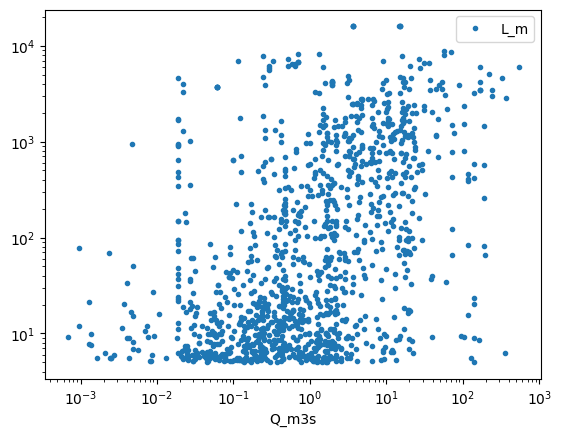

In [13]:
mod=smf.ols("np.log(L_m) ~ np.log(Q_m3s)",data=distances.clip(lower=1e-10)).fit()
print(mod.summary())
distances.plot(x="Q_m3s",y="L_m",marker=".",ls="none",logx=True,logy=True)

                            OLS Regression Results                            
Dep. Variable:            np.log(L_m)   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     7.561
Date:                Thu, 09 Apr 2026   Prob (F-statistic):            0.00605
Time:                        18:15:28   Log-Likelihood:                -2812.0
No. Observations:                1266   AIC:                             5628.
Df Residuals:                    1264   BIC:                             5638.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          4.2955      0.066     64.

<Axes: xlabel='omega0'>

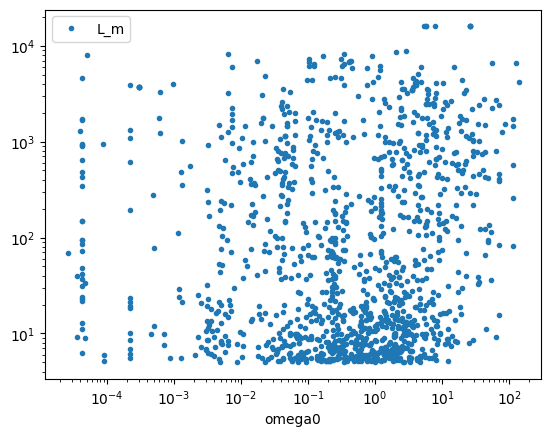

In [14]:
mod=smf.ols("np.log(L_m) ~ np.log(omega0)",data=distances.clip(lower=1e-10),missing="drop").fit()
print(mod.summary())
distances.plot(x="omega0",y="L_m",marker=".",ls="none",logx=True,logy=True)

Stream power has no explantory power for travel distance once mobilized than does discharge.  This makes a certain sense ... more movement in bigger rivers for same discharge.

In [15]:
def get_color(categories,cmap="magma"):
    uniques=list(set(categories))
    cm=mpl.colormaps[cmap]
    uniqdict=dict((unique,cm(float(j)/len(uniques))) for unique,j in zip(uniques,range(len(uniques))))
    return uniqdict

In [28]:
tzs={"socal":"US/Pacific","chicago":"US/Central","don":"US/Eastern","anacostia":"US/Eastern","miami":"US/Eastern","ipswich":"US/Eastern","sfbay":"US/Pacific"}

def get_cols(bottle):
    inds="Qmax lat lon totdasqkm slope_mean slope_std".split()
    return [bottle]+["{}_{}".format(ind,bottle) for ind in inds]

def width_dudley(area):
    return 0.3048 * ( 7.67 * ( 0.386102 * area) ** 0.52 )
#strm["width_m_dudley"] = 0.3048 * ( 7.67 * ( 0.386102 * strm["TotDASqKm"]) ** 0.52 )
#strm["width_m_lawlor"] = 0.3048 * ( 7.70 * ( 0.386102 * strm["TotDASqKm"]) ** 0.441)

inds=["00060","60","Qmax","lat","lon","totdasqkm","slope"]
def get_bottle_names(cols):
    return [x for x in cols if not any([x.startswith(ind) for ind in inds])]

def build_site_d(site_d,sta,tz):
    # mobilization distance stored as bottle name, Q as 00060.
    #  then slope and totdasqkm are by bottle.
    # No longer need the time domain.  Can reduce individual bottles 
    time = pd.to_datetime(site_d.index,utc=True).tz_convert(tz)
    site_d.index = time
    bottles=get_bottle_names(site_d) # function defined way above
    D = [] # empty - specify N-D?  Will be mob, Q, omega for this station
    #these={}
    for bottle in bottles:
        this = site_d["00060|{bot}|totdasqkm_{bot}|slope_mean_{bot}".format(bot=bottle).split('|')].rename(columns=dict([(k,v) for k,v in zip("{bot}|totdasqkm_{bot}|slope_mean_{bot}".format(bot=bottle).split('|'),"L_m totdasqkm slope".split())]))
        this["mob"] = (this["L_m"] > 0).astype(int)        
        this["totdasqkm slope".split()] = this["totdasqkm slope".split()].ffill().bfill()# (Forward fill for most, but backfill for early times)
        funcs={"L_m":"sum","mob":"max","00060":"mean","totdasqkm":"min","slope":"mean"}
        this = this.resample("1d").agg(funcs)
        this["Q_m3s"] = this["00060"] * (this["totdasqkm"] / areas[sta])
        this["omega0"] = this["Q_m3s"] * 1000.0 * 9.80 * this["slope"] / width_dudley(this["totdasqkm"])
        this=this.loc[this["omega0"] >= 1e-7]  # This is key to preventing kernel breakdown when we summarize by bin
        if len(this) == 0:
            continue
        this["duration_stay"]=0.0
        tfirst=this.index[0]
        this["duration"]=(this.index - tfirst).total_seconds() / 3600.
        this["bf_duration"]=np.nan
        lidx = (this["mob"]>0).astype(int).shift().fillna(0).astype(bool)
        this.loc[lidx,"bf_duration"]=this.loc[lidx,"duration"].values
        this.loc[tfirst,"bf_duration"] = 0.0
        this["bf_duration"] = this["bf_duration"].ffill()
        this["duration_stay"] = this["duration"] - this["bf_duration"]  
        #these[bottle]=this
        D.append(this["mob Q_m3s omega0 duration_stay".split()].values)
        
    D = np.concatenate(D)
    return D

2.220446049250313e-16
130.0
(2430, 1) (2430, 2)
17.692307692307693
{0: 0.11304347826086956, 1: 0.8869565217391304}
              precision    recall  f1-score   support

         0.0       0.94      0.95      0.94       743
         1.0       0.22      0.19      0.20        59

    accuracy                           0.89       802
   macro avg       0.58      0.57      0.57       802
weighted avg       0.88      0.89      0.89       802

0.8915211970074813
0.10086732321738029


/tmp/ipykernel_2522/4157707589.py:41: RuntimeWarning: divide by zero encountered in log
  X=np.log(d[:,2:]) # omega0 | durationStay
/home/shan/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


59.0
(3402, 1) (3402, 2)
56.66101694915254
{0: 0.03529763685312594, 1: 0.9647023631468741}
              precision    recall  f1-score   support

         0.0       0.92      0.99      0.95      1026
         1.0       0.43      0.10      0.17        97

    accuracy                           0.91      1123
   macro avg       0.68      0.55      0.56      1123
weighted avg       0.88      0.91      0.89      1123

0.9109528049866429
0.12229400901168791


/tmp/ipykernel_2522/4157707589.py:41: RuntimeWarning: divide by zero encountered in log
  X=np.log(d[:,2:]) # omega0 | durationStay
/home/shan/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


54.0
(2916, 1) (2916, 2)
53.0
{0: 0.03773584905660377, 1: 0.9622641509433962}
              precision    recall  f1-score   support

         0.0       0.89      0.98      0.94       857
         1.0       0.13      0.02      0.03       106

    accuracy                           0.88       963
   macro avg       0.51      0.50      0.48       963
weighted avg       0.81      0.88      0.84       963

0.8785046728971962
0.11051156958404358


...

10.0
(1596, 1) (1596, 2)
158.6
{0: 0.012610340479192938, 1: 0.987389659520807}
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98       507
         1.0       0.50      0.10      0.17        20

    accuracy                           0.96       527
   macro avg       0.73      0.55      0.57       527
weighted avg       0.95      0.96      0.95       527

0.9620493358633776
0.08415559772296016
57.0
(2717, 1) (2717, 2)
46.666666666666664
{0: 0.04285714285714286, 1: 0.9571428571428572}


/tmp/ipykernel_2522/4157707589.py:41: RuntimeWarning: divide by zero encountered in log
  X=np.log(d[:,2:]) # omega0 | durationStay
/home/shan/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/tmp/ipykernel_2522/4157707589.py:41: RuntimeWarning: divide by zero encountered in log
  X=np.log(d[:,2:]) # omega0 | durationStay
/home/shan/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


              precision    recall  f1-score   support

         0.0       0.95      0.99      0.97       845
         1.0       0.36      0.10      0.15        52

    accuracy                           0.94       897
   macro avg       0.65      0.54      0.56       897
weighted avg       0.91      0.94      0.92       897

0.9375696767001115
0.08673753782449435
9.0
(1260, 1) (1260, 2)
139.0
{0: 0.014388489208633094, 1: 0.9856115107913669}
              precision    recall  f1-score   support

         0.0       0.94      0.99      0.97       391
         1.0       0.50      0.08      0.14        25

    accuracy                           0.94       416
   macro avg       0.72      0.54      0.55       416
weighted avg       0.92      0.94      0.92       416

0.9399038461538461
0.09528846153846154


/tmp/ipykernel_2522/4157707589.py:41: RuntimeWarning: divide by zero encountered in log
  X=np.log(d[:,2:]) # omega0 | durationStay
/home/shan/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/tmp/ipykernel_2522/4157707589.py:41: RuntimeWarning: divide by zero encountered in log
  X=np.log(d[:,2:]) # omega0 | durationStay
/home/shan/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


13.0
(2121, 1) (2121, 2)
162.15384615384616
{0: 0.012333965844402276, 1: 0.9876660341555977}
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.98       682
         1.0       0.14      0.06      0.08        18

    accuracy                           0.97       700
   macro avg       0.56      0.52      0.53       700
weighted avg       0.95      0.97      0.96       700

0.9671428571428572
0.03222222222222222


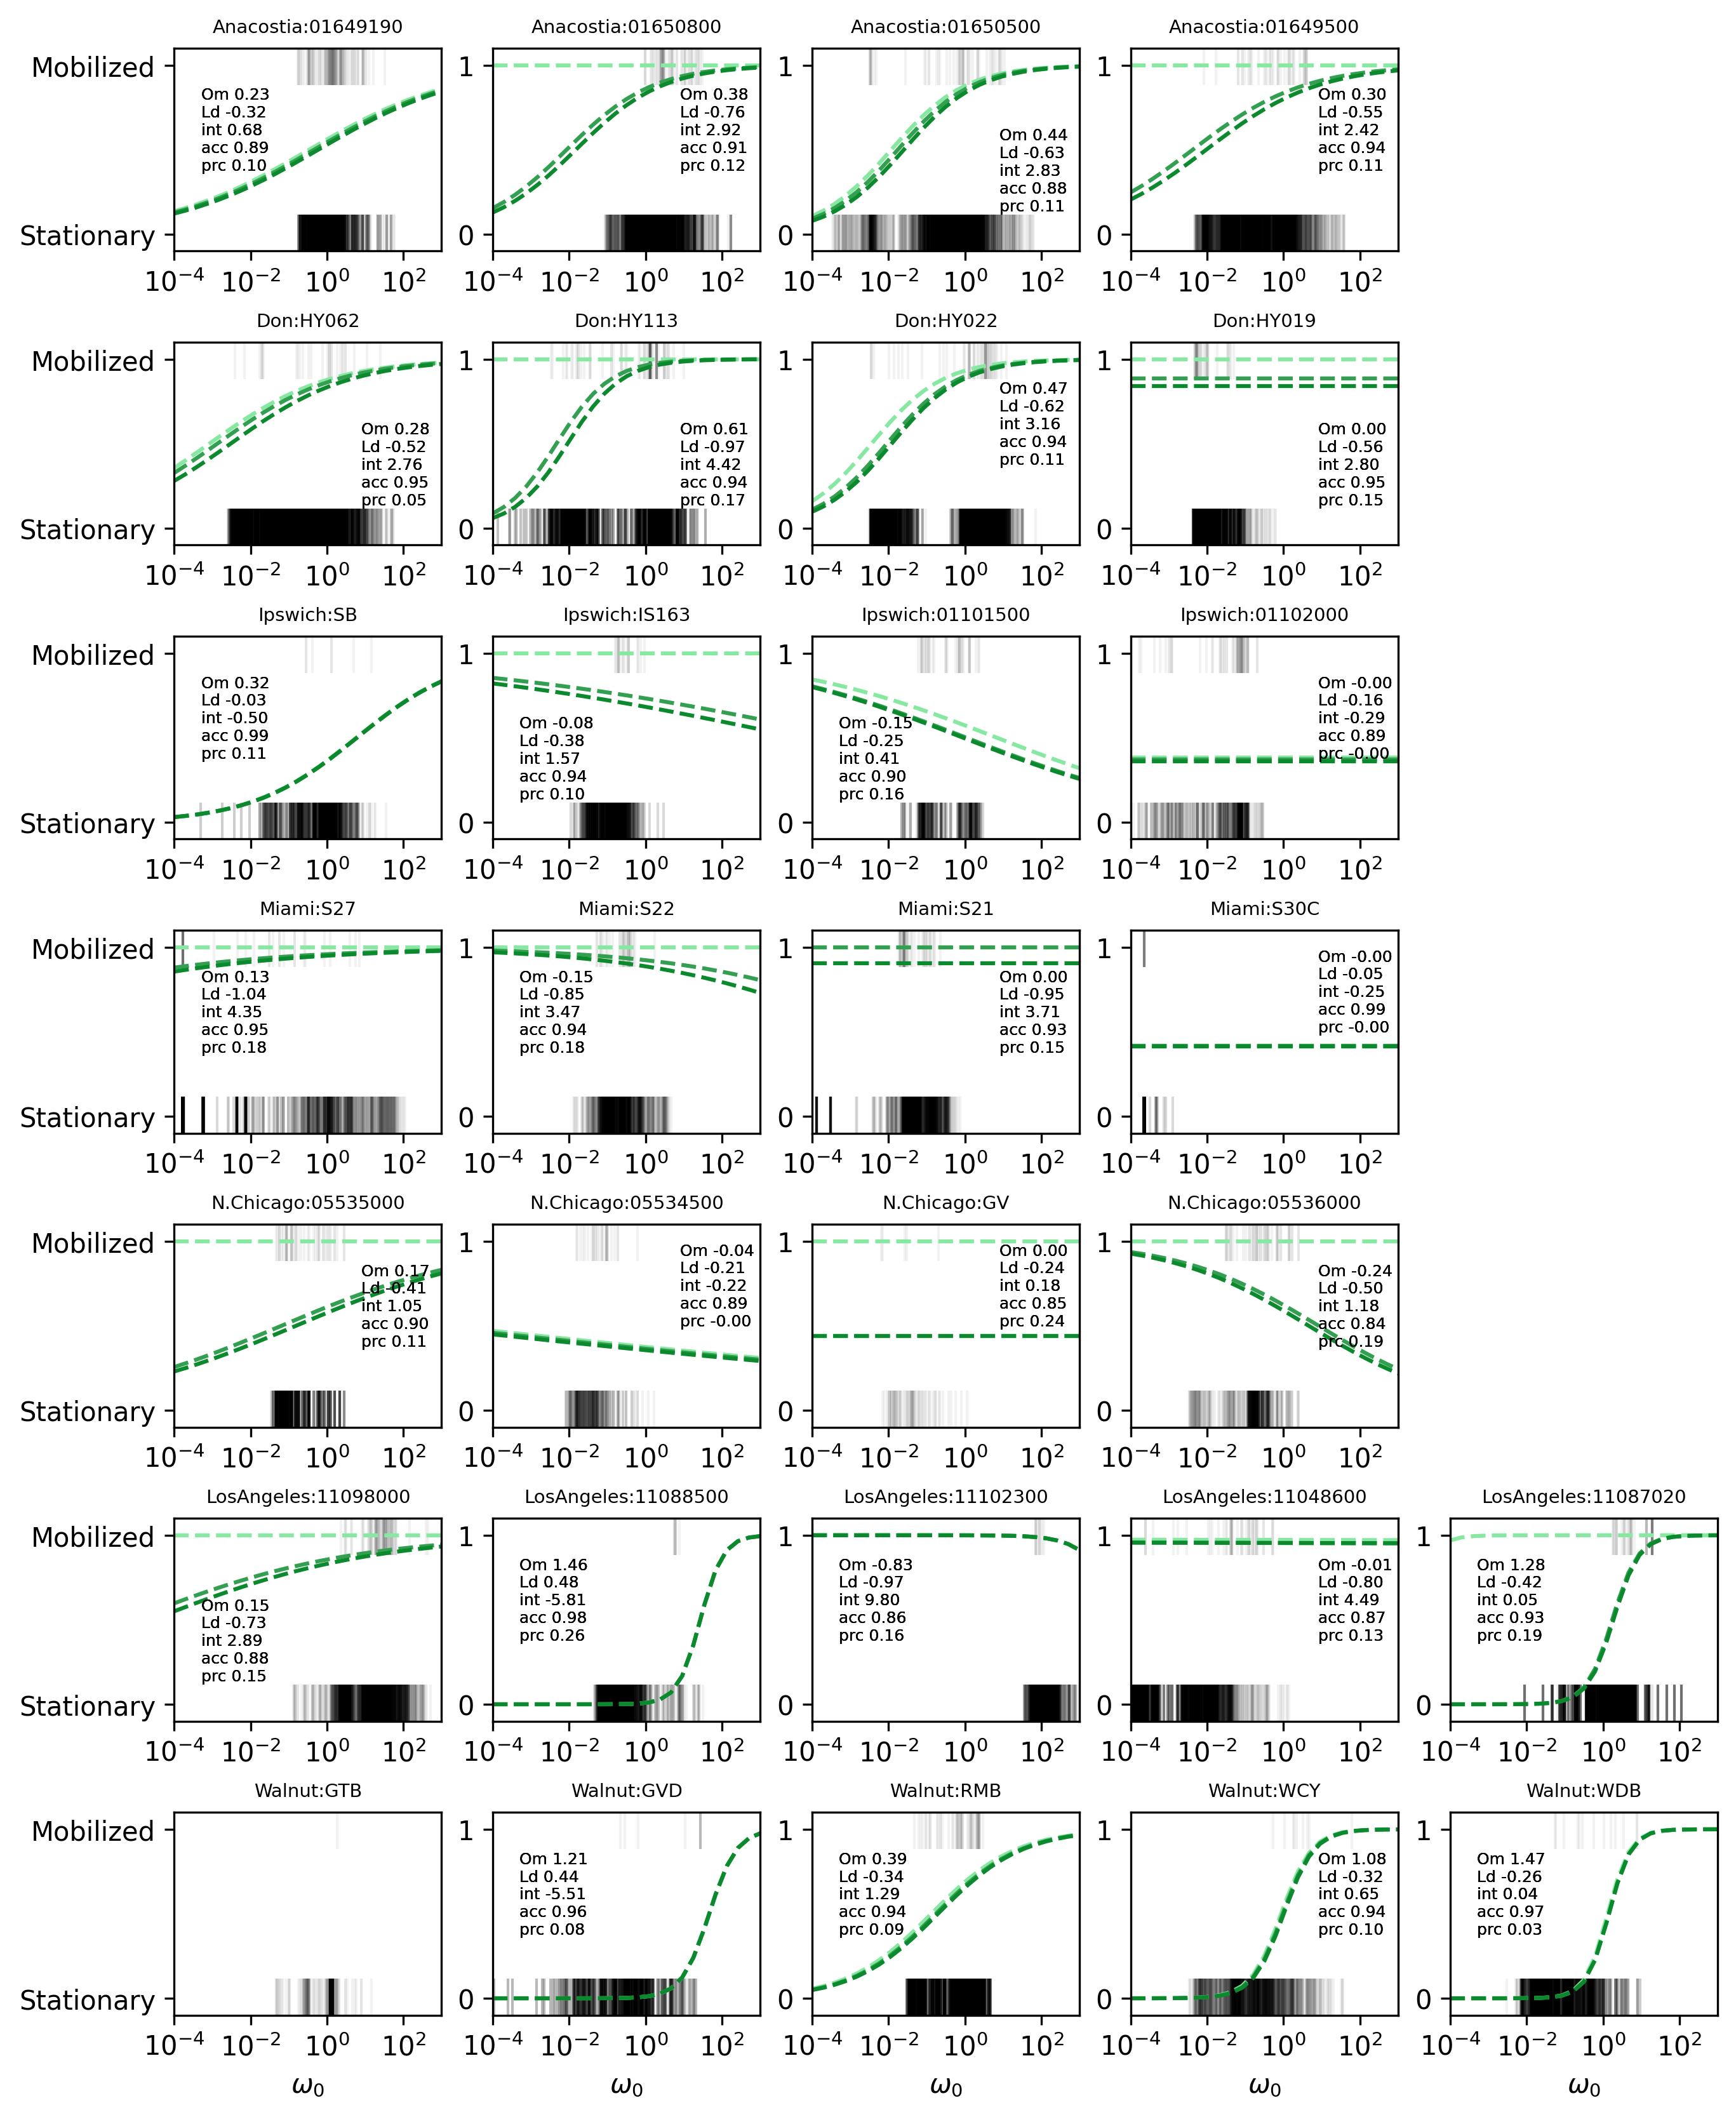

In [29]:
#fig,axs =plt.subplots(7,5,sharey="row",sharex="col",figsize=(9,11),dpi=300)
plot=True
logit=True
LinearBin = False
if plot:
    fig=plt.figure(constrained_layout=True,figsize=(9,11),dpi=300)
    gs=mpl.gridspec.GridSpec(7,5,figure=fig)
minq=low=1e-4
maxq=high=1e3

parms={}
eps=7./3 - 4./3 -1
print(eps)
axs=np.empty((7,5),dtype=mpl.axes.Axes)
    
default=(0.7,0.4)
text_locs={"01649190":(0.1,0.4),"01650800":default,"01650500":(0.7,0.2),"01649500":default, "HY062":(0.7,0.2),"HY113":(0.7,0.2),"HY022":default,"HY019":(0.7,0.2),
           "SB":(0.1,0.4),"IS163":(0.1,0.2),"01101500":(0.1,0.2),"01102000":(0.7,0.4),"S27":(0.1,0.4),"S22":(0.1,0.4),"S21":default,"S30C":(0.7,0.5),
           "05535000":(0.7,0.4),"05534500":(0.7,0.5),"GV":(0.7,0.5),"05536000":(0.7,0.4),"11098000":(0.1,0.2),"11088500":(0.1,0.4),"11102300":(0.1,0.4),
           "11048600":default,"11087020":(0.1,0.4),"GVD":(0.1,0.4),"RMB":(0.1,0.4),"WCY":default,"WDB":(0.1,0.4)}
for i,ws in enumerate(watersheds):
    D=data[ws]
    #print(i,ws)
    parms[ws]={}
    
    for j,sta in enumerate(reaches[ws]):
        #if j>3:
        #    continue # Sorry SF - only 4 sites allowed
        #print(sta)
        axs[i,j]=fig.add_subplot(gs[i,j])
        d=D[sta]
        d = build_site_d(d,sta,tzs[ws])
        print(d[:,0].sum())
        #print(np.nansum(d,axis=0))
        if plot:
            axs[i,j].plot(d[:,2], d[:,0],color='k',marker="|",ms=15,alpha=0.05,ls='none') #,legend=False)

        
        
        y=d[:,0:1]
        X=np.log(d[:,2:]) # omega0 | durationStay
        X[X<=0]=eps
        print(y.shape,X.shape)
        if logit:
            if y.sum() <= 1:
                print(sta,ws," total number of mobilizations: {}, neglecting. ...".format(y.sum()))
                parms[ws][sta]=(np.nan,np.nan,np.nan)
                continue
            B=(len(y)-y.sum())/y.sum()
            print(B)
            f=0.5 # how close to balanced?
            weights={0:1/f/B,1:1-1/f/B}
            print(weights)
            X_train, X_test, y_train, y_test = tts(X, y, test_size=0.33, random_state=42)
            #mod = sm.Logit(mobilizations.astype(int),np.log(omega0)).fit()
            #print(mod.summary())
            lr = LogisticRegression(class_weight=weights,penalty="l2",solver='lbfgs',C=1.).fit(X_train,y_train)  # balanced? class_weight="balanced"/"auto"?
            y_pred = lr.predict(X_test)
            print(classification_report(y_pred,y_test))
            print(accuracy_score(y_pred,y_test))
            print(average_precision_score(y_pred,y_test))
            q1,q2,q3=np.quantile(X[y[:,0]==1,1],[0.25,0.5,0.75])
            #parms[ws][sta]=(lr.coef_ + lr.intercept_,np.nan)
            X_plot=np.logspace(np.log(low),np.log(high),25,base=np.exp(1))[:]
            cs="#87e8a1 #32a050 #0b892d".split()
            for n,c,q in zip("short median long".split(),cs,[q1,q2,q3]):
                X_pred=np.stack((X_plot,q*np.ones_like(X_plot))).T
                #print(X_pred)
                y_prob=lr.predict_proba(np.log(X_pred))[:,1]
                #print(y_prob)
                parms[ws][sta]=tuple(lr.coef_[0])+(lr.intercept_[0],)
                if plot:
                    axs[i,j].plot(X_plot,y_prob,ls='--',color=c,label=n)
                    axs[i,j].text(*text_locs[sta],"Om {:0.2f} \nLd {:0.2f} \nint {:0.2f}\nacc {:0.2f} \nprc {:0.2f}".format(lr.coef_[0][0],
                                                                                                                    lr.coef_[0][1],lr.intercept_[0],
                                                                                                                   accuracy_score(y_pred,y_test),
                                                                                                                   average_precision_score(y_pred,y_test)),                                  
                                 transform=axs[i,j].transAxes,fontsize=6)
                    
            #mod = sm.Logit(endog=y.flatten(),exog=sm.add_constant(np.log10(x.flatten())),missing="drop").fit()
            
        if LinearBin:
            #print(int(np.log10(maxq)-np.log10(minq)))
            R=np.arange(-4,3,0.25) #np.linspace(np.log10(minq).astype(int),np.log10(maxq).astype(int),int(np.log10(maxq)-np.log10(minq)+1))
            #print(R)
            axb = axs[i,j].twinx()
            bn,fr=[],[]
            for lR,hR in zip(R[::],R[1::]):
                #print(lR,hR)
                lR,hR=10**lR,10**hR
                tmp = d[(d[:,2]>=lR)&(d[:,2]<hR),0]
                #tmp = tmp[[x for x in tmp.columns if x != "omega0"]].values.flatten()
                if len(tmp) == 0:
                    continue
                else:
                    pass
                    #print(tmp)
                mean = np.nansum(tmp)/(~np.isnan(tmp)).sum()
                std = np.nan
                #print(mean,std)
                #print(mean)
                if ~np.isnan(mean) and (mean > 0):
                    bn+=[np.mean([lR,hR])]
                    fr+=[mean]
                    if plot:
                        axb.plot(np.mean([lR,hR]),mean,'bo')
                if ~np.isnan(std):
                    if plot:
                        axb.errorbar(np.mean([lR,hR]),mean,yerr=std,color='b')
        
            datfr=pd.DataFrame.from_dict({"bn":bn,"fr":fr})
            datfr = np.log(datfr)
            print(datfr)
            
            
            if len(datfr) > 1:
                mod = smf.ols("fr ~ bn",data=datfr,missing="drop").fit()
                if plot:
                    axb.plot(10**R,np.exp(mod.params.iloc[0]+(np.log(10**R))*mod.params.iloc[1]),'c--')
                st,sdat,ss2 = summary_table(mod,alpha=0.05)
                fitted_values = sdat[:,2]
                predict_mean_ci_low,predict_mean_ci_upp = sdat[:,4:6].T
                print(np.exp(predict_mean_ci_low))
                print(10**datfr["bn"])
                if plot:
                    axb.fill_between(np.exp(datfr["bn"]),y1=np.exp(predict_mean_ci_low),y2=np.exp(predict_mean_ci_upp),facecolor="lightblue",interpolate=True,alpha=0.6,zorder=15)
                print(mod.summary())
        #print(mod.params)
        #print(mod.bse)
                parms[ws][sta]=(mod.params,mod.bse)
            #axb.plot(10**R,np.exp(mod.params[0])*(10**R)**mod.params[1],'k:')
            #mod.params
            else:
                parms[ws][sta]=(np.nan,np.nan)
            
            if plot:
                axb.set_ylim((1e-5,1e0))
                axb.set_yscale('log')
                if j < 4:
                    axb.set_yticklabels([])
                
                if (i == 3) & (j==3):
                    axb.set_ylabel("Fraction mobilized")
#axb
if plot:
    for i,ws in enumerate(watersheds):
        for j,sta in enumerate(reaches[ws]):
            axs[i,j].set_yticks([0,1])
            #axs[i,0].set_yticklabels(["Stationary","Mobilized"])
            axs[i,j].set_title("{}:{}".format(ws_names[ws],sta),fontsize=7)
            axs[i,j].set_xlim(minq,maxq)
            axs[i,j].set_ylim(-0.1,1.1)
            axs[i,j].set_xscale('log')
            axs[i,j].set_xlabel("")
        axs[i,0].set_yticklabels(["Stationary","Mobilized"])
    for j in range(5):
        axs[-1,j].set_xlabel("$\omega_0$")        
    plt.show()

In [30]:
default=(0.7,0.4)
text_locs={"01649190":(0.1,0.4),"01650800":default,"01650500":(0.7,0.2),"01649500":default, "HY062":(0.7,0.2),"HY113":(0.7,0.2),"HY022":default,"HY019":(0.7,0.2),
           "SB":(0.1,0.4),"IS163":(0.1,0.2),"01101500":(0.1,0.2),"01102000":(0.7,0.4),"S27":(0.1,0.4),"S22":(0.1,0.4),"S21":default,"S30C":(0.7,0.5),
           "05535000":(0.7,0.4),"05534500":(0.7,0.5),"GV":(0.7,0.5),"05536000":(0.7,0.4),"11098000":(0.1,0.2),"11088500":(0.1,0.4),"11102300":(0.1,0.4),
           "11048600":default,"11087020":(0.1,0.4),"GVD":(0.1,0.4),"RMB":(0.1,0.4),"WCY":default,"WDB":(0.1,0.4)}

In [31]:
parms

{'anacostia': {'01649190': (0.227316801862165,
   -0.3200910729332859,
   0.6774715439009132),
  '01650800': (0.38315265581750985, -0.758145267867759, 2.9246606043198535),
  '01650500': (0.4449731107002344, -0.6283365204436774, 2.8261891758347955),
  '01649500': (0.29772460546373586, -0.5513110596132378, 2.422356725063252)},
 'don': {'HY062': (0.278037724671053, -0.5218808498955511, 2.7649011904059),
  'HY113': (0.6128386593443381, -0.9719742687012892, 4.422717820194513),
  'HY022': (0.4656747640685539, -0.6179176358246882, 3.1618737133073744),
  'HY019': (5.631325968346838e-16, -0.564850210248474, 2.8031726977279314)},
 'ipswich': {'SB': (0.31531739176686485,
   -0.033400567430613884,
   -0.4957784962252046),
  'IS163': (-0.08235589632312203, -0.3757019848296045, 1.5658081425579986),
  '01101500': (-0.15198081891585344, -0.2459909605615383, 0.40679890425320553),
  '01102000': (-3.975373335059722e-17,
   -0.16035654459912188,
   -0.2943604724632167)},
 'miami': {'S27': (0.1258875665958

In [32]:
tzs={"socal":"US/Pacific","chicago":"US/Central","don":"US/Eastern","anacostia":"US/Eastern","miami":"US/Eastern","ipswich":"US/Eastern","sfbay":"US/Pacific"}

In [33]:
#fig,axs =plt.subplots(7,5,sharey="row",sharex="col",figsize=(9,11),dpi=300)
#fig=plt.figure(constrained_layout=True,figsize=(9,11),dpi=300)
#gs=mpl.gridspec.GridSpec(7,5,figure=fig)
minq=1e-4
maxq=1e3
eps=7./3 - 4./3 -1
print(eps)
mobilizations=np.array([])
flows=np.array([])
omega0=np.array([])
stays =np.array([])

# Raw arrays, not pruning poorly behaving sites
rmobilizations=np.array([])
rflows=np.array([])
romega0=np.array([])
rstays =np.array([])

# Build_site_d is defined above.
goodSites=0
for i,ws in enumerate(watersheds):
    D=data[ws]
    print(i,ws)
    tz = tzs[ws]
        
    for j,sta in enumerate(reaches[ws]):
        
        d=D[sta]
        d = build_site_d(d,sta,tz)
                
        y=d[:,0]
        x=d[:,1]
        z=d[:,2]
        w=d[:,3]
        x[x<=0]=eps
        z[z<=0]=eps
        w[w<=0]=eps
        rmobilizations=np.concatenate((rmobilizations,y))
        rflows=np.concatenate((rflows,x))
        romega0=np.concatenate((romega0,z))
        rstays=np.concatenate((rstays,w))

        if (type(parms[ws][sta][0]) == float):
            continue
        elif (parms[ws][sta][0] <= 0) | (parms[ws][sta][1] >= 0):
            continue
        goodSites+=1
        mobilizations=np.concatenate((mobilizations,y))
        flows=np.concatenate((flows,x))
        omega0=np.concatenate((omega0,z))
        stays=np.concatenate((stays,w))

        #mod = sm.Logit(endog=y.flatten(),exog=sm.add_constant(np.log10(x.flatten())),missing="drop").fit()
        #print(mod.summary())
print(goodSites," Good sites aggregated")

2.220446049250313e-16
0 anacostia
1 don
2 ipswich
3 miami
4 chicago
5 socal
6 sfbay
18  Good sites aggregated


In [34]:
dat = np.vstack((mobilizations,flows,omega0,stays))
print(dat.shape)
np.save(fldr+"mobilizations.npy",dat)
dat = np.vstack((rmobilizations,rflows,romega0,rstays))
print(dat.shape)
np.save(fldr+"rmobilizations.npy",dat)

(4, 48603)
(4, 64407)


In [23]:
print(deploy["site_no"].unique())

['01102000' '01101500' 'IS163' 'SB' '05535000' '05534500' 'GV' '05536000'
 'HY113' 'HY022' 'HY062' 'HY019' nan '01650800' '01649500' '01649190'
 '01650500' 'S30C' 'S27' 'S22' 'S21' 'S28' 'WDB' 'WCY' 'RMB' 'GVD' 'GTB'
 '11102300' '11098000' '11048600' '11087020' '11088500']


In [24]:
data["socal"]["11102300"]

,Elkhorn Coral_1,00060,Qmax_Elkhorn Coral_1,lat_Elkhorn Coral_1,lon_Elkhorn Coral_1,totdasqkm_Elkhorn Coral_1,slope_mean_Elkhorn Coral_1,slope_std_Elkhorn Coral_1,Anchovy_1,Qmax_Anchovy_1,...,totdasqkm_Marlin_1_1,slope_mean_Marlin_1_1,slope_std_Marlin_1_1,Clam_0,Qmax_Clam_0,lat_Clam_0,lon_Clam_0,totdasqkm_Clam_0,slope_mean_Clam_0,slope_std_Clam_0
2024-01-03 04:45:00-08:00,0.0,3.341388,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-03 05:00:00-08:00,0.0,3.681190,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-03 05:15:00-08:00,0.0,3.681190,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-03 05:30:00-08:00,0.0,5.889904,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-03 05:45:00-08:00,0.0,4.955448,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-03 17:30:00-07:00,0.0,2.973269,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2024-07-03 17:45:00-07:00,0.0,2.973269,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2024-07-03 18:00:00-07:00,0.0,2.973269,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2024-07-03 18:15:00-07:00,0.0,2.973269,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
deploy.loc[deploy.site_no =='11102300']

,River,Deployment site,Deployment Lat,Deployment Long,site_no,Deployment date,Deployment time,Water depth at deployment site @ point of release (m),River width at deployment site (m),Distance deployment from left bank (m),...,Habitat of first retainment,Fate,# ID,Return,Habitat of first retainment,Returned,River width at deployment site (m),Stage (m),site_no.1,Velocity (m/s)
Bottle ID,,,,,,,,,,,,,,,,,,,,,
Blue tang,LA River,LA mainstem,34.085541,-118.228113,11102300,2024-01-18 00:00:00,10:00:00,0.084,69.4,20.9,...,NaN,NaN,NaN,NaN,"Fairly clear stream, some submergent vegetatio...",NaN,NaN,NaN,NaN,2.209
Elkhorn Coral,LA River,LA mainstem,34.085541,-118.228113,11102300,2024-01-18 00:00:00,10:00:00,0.084,69.4,20.9,...,NaN,NaN,NaN,NaN,"Fairly clear stream, some submergent vegetatio...",NaN,NaN,NaN,NaN,2.209
Anchovy,LA River,LA mainstem,34.085541,-118.228113,11102300,2024-01-18 00:00:00,10:00:00,0.084,69.4,20.9,...,NaN,NaN,NaN,NaN,"Fairly clear stream, some submergent vegetatio...",NaN,NaN,NaN,NaN,2.209
Albatross,LA River,LA mainstem,34.085541,-118.228113,11102300,2024-01-18 00:00:00,10:00:00,0.084,69.4,20.9,...,NaN,NaN,NaN,NaN,"Fairly clear stream, some submergent vegetatio...",NaN,NaN,NaN,NaN,2.209
Loggerhead turtle,LA River,LA mainstem,34.085541,-118.228113,11102300,2024-01-18 00:00:00,10:00:00,0.084,69.4,20.9,...,NaN,NaN,NaN,NaN,"Fairly clear stream, some submergent vegetatio...",NaN,NaN,NaN,NaN,2.209
Marlin,LA River,LA mainstem,34.085541,-118.228113,11102300,2024-01-18 00:00:00,10:00:00,0.084,69.4,20.9,...,NaN,NaN,NaN,NaN,"Fairly clear stream, some submergent vegetatio...",NaN,NaN,NaN,NaN,2.209
Mangrove crab,LA River,LA mainstem,34.085541,-118.228113,11102300,2024-01-18 00:00:00,10:00:00,0.084,69.4,20.9,...,NaN,NaN,NaN,NaN,"Fairly clear stream, some submergent vegetatio...",NaN,NaN,NaN,NaN,2.209
Basket star,LA River,LA mainstem,34.085541,-118.228113,11102300,2024-01-18 00:00:00,10:00:00,0.084,69.4,20.9,...,NaN,NaN,NaN,NaN,"Fairly clear stream, some submergent vegetatio...",NaN,NaN,NaN,NaN,2.209
Clam,LA River,LA mainstem,34.085541,-118.228113,11102300,2024-01-18 00:00:00,10:00:00,0.084,69.4,20.9,...,NaN,NaN,NaN,NaN,"Fairly clear stream, some submergent vegetatio...",NaN,NaN,NaN,NaN,2.209


In [26]:
deploy.loc[deploy.site_no =='11102300']

,River,Deployment site,Deployment Lat,Deployment Long,site_no,Deployment date,Deployment time,Water depth at deployment site @ point of release (m),River width at deployment site (m),Distance deployment from left bank (m),...,Habitat of first retainment,Fate,# ID,Return,Habitat of first retainment,Returned,River width at deployment site (m),Stage (m),site_no.1,Velocity (m/s)
Bottle ID,,,,,,,,,,,,,,,,,,,,,
Blue tang,LA River,LA mainstem,34.085541,-118.228113,11102300,2024-01-18 00:00:00,10:00:00,0.084,69.4,20.9,...,NaN,NaN,NaN,NaN,"Fairly clear stream, some submergent vegetatio...",NaN,NaN,NaN,NaN,2.209
Elkhorn Coral,LA River,LA mainstem,34.085541,-118.228113,11102300,2024-01-18 00:00:00,10:00:00,0.084,69.4,20.9,...,NaN,NaN,NaN,NaN,"Fairly clear stream, some submergent vegetatio...",NaN,NaN,NaN,NaN,2.209
Anchovy,LA River,LA mainstem,34.085541,-118.228113,11102300,2024-01-18 00:00:00,10:00:00,0.084,69.4,20.9,...,NaN,NaN,NaN,NaN,"Fairly clear stream, some submergent vegetatio...",NaN,NaN,NaN,NaN,2.209
Albatross,LA River,LA mainstem,34.085541,-118.228113,11102300,2024-01-18 00:00:00,10:00:00,0.084,69.4,20.9,...,NaN,NaN,NaN,NaN,"Fairly clear stream, some submergent vegetatio...",NaN,NaN,NaN,NaN,2.209
Loggerhead turtle,LA River,LA mainstem,34.085541,-118.228113,11102300,2024-01-18 00:00:00,10:00:00,0.084,69.4,20.9,...,NaN,NaN,NaN,NaN,"Fairly clear stream, some submergent vegetatio...",NaN,NaN,NaN,NaN,2.209
Marlin,LA River,LA mainstem,34.085541,-118.228113,11102300,2024-01-18 00:00:00,10:00:00,0.084,69.4,20.9,...,NaN,NaN,NaN,NaN,"Fairly clear stream, some submergent vegetatio...",NaN,NaN,NaN,NaN,2.209
Mangrove crab,LA River,LA mainstem,34.085541,-118.228113,11102300,2024-01-18 00:00:00,10:00:00,0.084,69.4,20.9,...,NaN,NaN,NaN,NaN,"Fairly clear stream, some submergent vegetatio...",NaN,NaN,NaN,NaN,2.209
Basket star,LA River,LA mainstem,34.085541,-118.228113,11102300,2024-01-18 00:00:00,10:00:00,0.084,69.4,20.9,...,NaN,NaN,NaN,NaN,"Fairly clear stream, some submergent vegetatio...",NaN,NaN,NaN,NaN,2.209
Clam,LA River,LA mainstem,34.085541,-118.228113,11102300,2024-01-18 00:00:00,10:00:00,0.084,69.4,20.9,...,NaN,NaN,NaN,NaN,"Fairly clear stream, some submergent vegetatio...",NaN,NaN,NaN,NaN,2.209


In [27]:
S28 nan  11092450| 

SyntaxError: invalid syntax (2195745098.py, line 1)